# **SGD CLASSIFIER**

In [1]:
from utils import *

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import classification_report, f1_score, confusion_matrix

import optuna
from functools import partial
from sklearn.utils import shuffle

/home/n.emmolo/miniconda3/envs/env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Ignore warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

In [3]:
# -----------------------
# Model building function
# -----------------------

def build_model(loss="hinge", penalty="l2", alpha=1e-4, learning_rate="optimal", eta0=0.001):
    """
    Builds a scikit-learn Pipeline with TF-IDF vectorization and SGDClassifier (incremental SVM-like model).

    Args:
        loss (str): Loss function
        penalty (str): Regularization type
        alpha (float): Regularization strength
        learning_rate (str): Learning rate schedule
        eta0 (float): Initial learning rate

    Returns:
        Pipeline: TF-IDF + SGDClassifier pipeline.
    """
    return Pipeline([
        ('tfidf', TfidfVectorizer(  # TD-IDF vectorization inside pipeline
            max_features=5000,      # limit to top 5000 features
            ngram_range=(1, 2),     # unigrams + bigrams
            stop_words="english"    # remove English stop words
        )),
        ('clf', SGDClassifier(      # SGD Classifier
            loss=loss,
            penalty=penalty,
            alpha=alpha,
            learning_rate=learning_rate,
            eta0=eta0,
            max_iter=5,
            random_state=42
        ))
    ])


In [4]:
# -------------------------
# Optuna objective function
# -------------------------

def objectiveSGD(trial, X_train, y_train, X_val, y_val):
    """
    Objective function for Optuna hyperparameter optimization of SGDClassifier model.

    Args:
        trial: An Optuna trial object for suggesting hyperparameters
        X_train: Training feature data
        y_train: Training labels
        X_val: Validation feature data
        y_val: Validation labels
    
    Returns:
        float: The weighted F1-score on the validation set
    """

    loss = trial.suggest_categorical("loss", ["hinge", "log_loss", "modified_huber", "squared_hinge"])
    penalty = trial.suggest_categorical("penalty", ["l1", "l2", "elasticnet"])
    alpha = trial.suggest_categorical("alpha", [1e-6, 1e-5, 1e-4, 1e-3, 1e-2])
    learning_rate = trial.suggest_categorical("learning_rate", ["optimal", "constant", "adaptive", "invscaling"])
    eta0 = trial.suggest_categorical("eta0", [0.0001, 0.001, 0.01, 0.1])

    model = build_model(
        loss=loss,
        penalty=penalty,
        alpha=alpha,
        learning_rate=learning_rate,
        eta0=eta0
    )

    try:
        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        f1 = f1_score(y_val, preds, average="weighted") # weighted F1-score: average for label imbalance
        return f1

    except Exception as e:
        return 0.0 # return a default value in case of failure


## VERSION 1: Dataset by Topic

In [5]:
dataset_df = data_by_topic()

print("--- DATASET SIZES BY TOPIC ---")
for topic, df in dataset_df.items():
    print(f"Topic: {topic}, Number of samples: {len(df)}")

--- DATASET SIZES BY TOPIC ---
Topic: politics, Number of samples: 97476
Topic: general, Number of samples: 12845
Topic: covid, Number of samples: 10559
Topic: syria, Number of samples: 842
Topic: islam, Number of samples: 722
Topic: notredame, Number of samples: 554
Topic: gossip, Number of samples: 500


In [6]:
# --------------
# Split datasets
# --------------

datasets = {topic: split_dataset(df) for topic, df in dataset_df.items()} # split all datasets in train/val/test

print("--- DATA SPLITS SIZES BY TOPIC ---")
for topic, data_splits in datasets.items():
    print(f"Topic: {topic}")
    print(f"Train: {len(data_splits['train'][0])}, Val: {len(data_splits['val'][0])}, Test: {len(data_splits['test'][0])}")

--- DATA SPLITS SIZES BY TOPIC ---
Topic: politics
Train: 58485, Val: 19495, Test: 19496
Topic: general
Train: 7707, Val: 2569, Test: 2569
Topic: covid
Train: 6335, Val: 2112, Test: 2112
Topic: syria
Train: 505, Val: 168, Test: 169
Topic: islam
Train: 433, Val: 144, Test: 145
Topic: notredame
Train: 332, Val: 111, Test: 111
Topic: gossip
Train: 300, Val: 100, Test: 100


In [ ]:
# ---------------------------
# Hyperparameter optimization
# ---------------------------

# merge all training and validation data across topics for optimization
X_train = pd.concat([datasets[topic]['train'][0] for topic in datasets]).reset_index(drop=True)
y_train = pd.concat([datasets[topic]['train'][1] for topic in datasets]).reset_index(drop=True)
X_val = pd.concat([datasets[topic]['val'][0] for topic in datasets]).reset_index(drop=True)
y_val = pd.concat([datasets[topic]['val'][1] for topic in datasets]).reset_index(drop=True)
# shuffle the combined training and validation data
X_train, y_train = shuffle(X_train, y_train, random_state=42)
X_val, y_val = shuffle(X_val, y_val, random_state=42)

# functools.partial to pass data to objective function
objective_with_data = partial(objectiveSGD,
                              X_train=X_train,
                              X_val=X_val,
                              y_train=y_train,
                              y_val=y_val)

study = optuna.create_study(direction="maximize") # maximize F1-score
study.optimize(objective_with_data, n_trials=100) # 100 trials for demonstration; increase for better results

print("Best parameters:", study.best_params)

[I 2025-11-11 17:04:09,591] A new study created in memory with name: no-name-08ae5b74-9c27-454b-8f88-0338612604be


[I 2025-11-11 17:04:58,932] Trial 0 finished with value: 0.8552730784279149 and parameters: {'loss': 'modified_huber', 'penalty': 'elasticnet', 'alpha': 0.001, 'learning_rate': 'constant', 'eta0': 0.01}. Best is trial 0 with value: 0.8552730784279149.
[I 2025-11-11 17:05:47,749] Trial 1 finished with value: 0.7861913684314107 and parameters: {'loss': 'modified_huber', 'penalty': 'l2', 'alpha': 0.0001, 'learning_rate': 'constant', 'eta0': 0.0001}. Best is trial 0 with value: 0.8552730784279149.
[I 2025-11-11 17:06:36,279] Trial 2 finished with value: 0.46804757830001104 and parameters: {'loss': 'hinge', 'penalty': 'l1', 'alpha': 0.01, 'learning_rate': 'constant', 'eta0': 0.1}. Best is trial 0 with value: 0.8552730784279149.
[I 2025-11-11 17:07:24,454] Trial 3 finished with value: 0.8571526939970504 and parameters: {'loss': 'squared_hinge', 'penalty': 'l2', 'alpha': 1e-05, 'learning_rate': 'optimal', 'eta0': 0.0001}. Best is trial 3 with value: 0.8571526939970504.
[I 2025-11-11 17:08:12,

Best parameters: {'loss': 'squared_hinge', 'penalty': 'elasticnet', 'alpha': 1e-06, 'learning_rate': 'constant', 'eta0': 0.1}


In [ ]:
# -------------------------------
# Fine-tuning on Dataset by Topic
# -------------------------------

best_params = study.best_params
best_model = build_model(
    loss=best_params["loss"],
    penalty=best_params["penalty"],
    alpha=best_params["alpha"],
    learning_rate=best_params["learning_rate"],
    eta0=best_params["eta0"]
)

results_topic = {}
results_full = {}
X_full_test = pd.concat([datasets[t]["test"][0] for t in datasets]).reset_index(drop=True)
y_full_test = pd.concat([datasets[t]["test"][1] for t in datasets]).reset_index(drop=True)

# sequential training
for i, (topic, data) in enumerate(datasets.items()):
    print(f"\n=== Phase {i+1}: Training/Fine-tuning on topic: {topic} ===")
    
    X_train, y_train = data["train"]
    X_val, y_val = data["val"]
    X_test, y_test = data["test"]
    
    # incremental fit (on train+val)
    best_model.named_steps['clf'].partial_fit(
        best_model.named_steps['tfidf'].fit_transform(pd.concat([X_train, X_val])),
        pd.concat([y_train, y_val]),
        classes=[0, 1] # possible classes: assuming binary classification
    )

    y_pred = best_model.predict(X_test)
    print(f"Classification Report after topic {topic}:")
    print(classification_report(y_test, y_pred))
    print(f"Confusion Matrix after topic {topic}:")
    print(confusion_matrix(y_test, y_pred))
    print(f"\nWeighted F1-score after topic {topic}:", f1_score(y_test, y_pred, average="weighted"))


    # evaluation on all topics
    print("\n--- Evaluation on all topics ---")
    results_topic[topic] = {}
    for test_topic, test_data in datasets.items(): # for each topic
        X_te, y_te = test_data["test"]
        preds = best_model.predict(X_te)
        f1 = f1_score(y_te, preds, average="weighted")
        results_topic[topic][test_topic] = f1
        print(f"Evaluation on topic {test_topic}: Weighted F1 = {f1:.4f}")

    # evaluation on full test set
    print("\n--- Evaluation on full test set ---")
    preds_full = best_model.predict(X_full_test)
    f1_full = f1_score(y_full_test, preds_full, average="weighted")
    results_full[topic] = f1_full
    print(f"Evaluation on full test set after topic {topic}: Weighted F1 = {f1_full:.4f}")


=== Phase 1: Training/Fine-tuning on topic: politics ===
Classification Report after topic politics:
              precision    recall  f1-score   support

         0.0       0.94      0.93      0.94     10094
         1.0       0.93      0.94      0.93      9402

    accuracy                           0.93     19496
   macro avg       0.93      0.93      0.93     19496
weighted avg       0.93      0.93      0.93     19496

Confusion Matrix after topic politics:
[[9400  694]
 [ 606 8796]]

Weighted F1-score after topic politics: 0.9333289887907166

--- Evaluation on all topics ---
Evaluation on topic politics: Weighted F1 = 0.9333
Evaluation on topic general: Weighted F1 = 0.2312
Evaluation on topic covid: Weighted F1 = 0.3729
Evaluation on topic syria: Weighted F1 = 0.4580
Evaluation on topic islam: Weighted F1 = 0.4798
Evaluation on topic notredame: Weighted F1 = 0.3194
Evaluation on topic gossip: Weighted F1 = 0.3912

--- Evaluation on full test set ---
Evaluation on full test set 

In [ ]:
# ---------------
# Results summary
# ---------------

print("\n=== Results Summary ===")
for topic, res in results_topic.items():
    print(f"\nResults after training on topic {topic}:")
    for test_topic, f1 in res.items():
        print(f"  Test on topic {test_topic}: Weighted F1 = {f1:.4f}")
    
print("\nResults on full test set after each topic training:")
for topic, f1 in results_full.items():
    print(f"  After training on topic {topic}: Weighted F1 = {f1:.4f}")


=== Results Summary ===

Results after training on topic politics:
  Test on topic politics: Weighted F1 = 0.9333
  Test on topic general: Weighted F1 = 0.2312
  Test on topic covid: Weighted F1 = 0.3729
  Test on topic syria: Weighted F1 = 0.4580
  Test on topic islam: Weighted F1 = 0.4798
  Test on topic notredame: Weighted F1 = 0.3194
  Test on topic gossip: Weighted F1 = 0.3912

Results after training on topic general:
  Test on topic politics: Weighted F1 = 0.3559
  Test on topic general: Weighted F1 = 0.9701
  Test on topic covid: Weighted F1 = 0.3708
  Test on topic syria: Weighted F1 = 0.3633
  Test on topic islam: Weighted F1 = 0.4333
  Test on topic notredame: Weighted F1 = 0.4654
  Test on topic gossip: Weighted F1 = 0.3333

Results after training on topic covid:
  Test on topic politics: Weighted F1 = 0.4018
  Test on topic general: Weighted F1 = 0.2519
  Test on topic covid: Weighted F1 = 0.9218
  Test on topic syria: Weighted F1 = 0.4262
  Test on topic islam: Weighted F

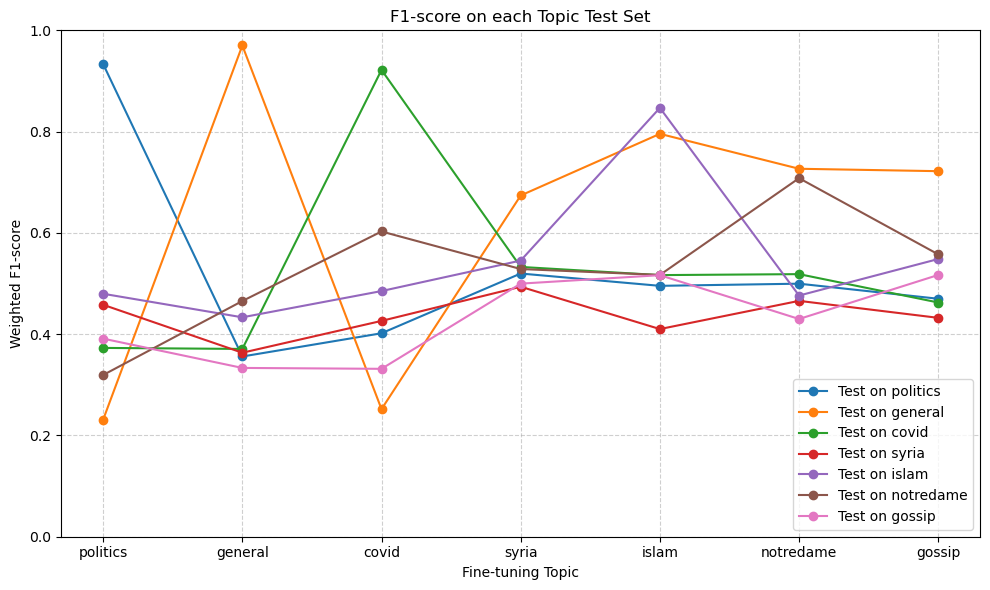

In [10]:
# ------------------
# Plot on each Topic
# ------------------

# extract topics
topics = list(results_topic.keys())
test_topics = list(next(iter(results_topic.values())).keys())

# make F1-score matrix
f1_matrix = np.array([[results_topic[train_topic][test_topic] for test_topic in test_topics] for train_topic in topics])

plt.figure(figsize=(10, 6))

# plot each test topic line
for i, test_topic in enumerate(test_topics):
    plt.plot(topics, f1_matrix[:, i], marker='o', label=f"Test on {test_topic}")

plt.title("F1-score on each Topic Test Set")
plt.xlabel("Fine-tuning Topic")
plt.ylabel("Weighted F1-score")
plt.ylim(0, 1)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

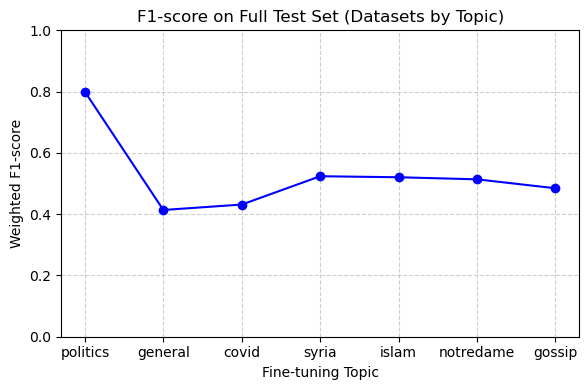

In [ ]:
# ---------------------
# Plot on Full Test Set
# ---------------------

plt.figure(figsize=(6, 4))

# plot F1-score on full test set
plt.plot(topics, [results_full[topic] for topic in topics], marker='o', color='b')

plt.title("F1-score on Full Test Set (Datasets by Topic)")
plt.xlabel("Fine-tuning Topic")
plt.ylabel("Weighted F1-score")
plt.ylim(0, 1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## VERSION 2: Dataset by Date

In [5]:
dataset_df = data_by_date()

print("\n--- DATASET SIZES BY DATE ---")
for date, df in dataset_df.items():
    print(f"Date: {date}, Number of samples: {len(df)}")


--- DATASET SIZES BY DATE ---
Date: 2011-2013, Number of samples: 55
Date: 2014, Number of samples: 114
Date: 2015, Number of samples: 84
Date: 2016, Number of samples: 63018
Date: 2017, Number of samples: 16657
Date: 2019, Number of samples: 554
Date: 2020, Number of samples: 10559


In [13]:
# --------------
# Split datasets
# --------------

datasets = {date: split_dataset(df) for date, df in dataset_df.items()} # split all datasets in train/val/test

print("--- DATA SPLITS SIZES BY DATE ---")
for date, data_splits in datasets.items():
    print(f"Date: {date}")
    print(f"Train: {len(data_splits['train'][0])}, Val: {len(data_splits['val'][0])}, Test: {len(data_splits['test'][0])}")

--- DATA SPLITS SIZES BY DATE ---
Date: 2011-2013
Train: 33, Val: 11, Test: 11
Date: 2014
Train: 68, Val: 23, Test: 23
Date: 2015
Train: 50, Val: 17, Test: 17
Date: 2016
Train: 37810, Val: 12604, Test: 12604
Date: 2017
Train: 9994, Val: 3331, Test: 3332
Date: 2019
Train: 332, Val: 111, Test: 111
Date: 2020
Train: 6335, Val: 2112, Test: 2112


In [ ]:
# ---------------------------
# Hyperparameter optimization
# ---------------------------

# merge all training and validation data across dates for optimization
X_train = pd.concat([datasets[date]['train'][0] for date in datasets]).reset_index(drop=True)
y_train = pd.concat([datasets[date]['train'][1] for date in datasets]).reset_index(drop=True)
X_val = pd.concat([datasets[date]['val'][0] for date in datasets]).reset_index(drop=True)
y_val = pd.concat([datasets[date]['val'][1] for date in datasets]).reset_index(drop=True)
# shuffle the combined training and validation data
X_train, y_train = shuffle(X_train, y_train, random_state=42)
X_val, y_val = shuffle(X_val, y_val, random_state=42)

# functools.partial to pass data to objective function
objective_with_data = partial(objectiveSGD,
                              X_train=X_train,
                              X_val=X_val,
                              y_train=y_train,
                              y_val=y_val)

study = optuna.create_study(direction="maximize") # maximize F1-score
study.optimize(objective_with_data, n_trials=100) # 100 trials for demonstration; increase for better results

print("Best parameters:", study.best_params)

[I 2025-11-11 18:36:13,043] A new study created in memory with name: no-name-6bf435a5-2a2b-4ef8-94cb-1e915843da46
[I 2025-11-11 18:36:55,380] Trial 0 finished with value: 0.5537743344801894 and parameters: {'loss': 'squared_hinge', 'penalty': 'l2', 'alpha': 0.01, 'learning_rate': 'invscaling', 'eta0': 0.0001}. Best is trial 0 with value: 0.5537743344801894.
[I 2025-11-11 18:37:37,845] Trial 1 finished with value: 0.6942174642601482 and parameters: {'loss': 'modified_huber', 'penalty': 'l2', 'alpha': 1e-06, 'learning_rate': 'constant', 'eta0': 0.0001}. Best is trial 1 with value: 0.6942174642601482.
[I 2025-11-11 18:38:20,586] Trial 2 finished with value: 0.8950629795713676 and parameters: {'loss': 'squared_hinge', 'penalty': 'elasticnet', 'alpha': 0.001, 'learning_rate': 'constant', 'eta0': 0.01}. Best is trial 2 with value: 0.8950629795713676.
[I 2025-11-11 18:39:03,317] Trial 3 finished with value: 0.9194373930539246 and parameters: {'loss': 'hinge', 'penalty': 'elasticnet', 'alpha':

Best parameters: {'loss': 'log_loss', 'penalty': 'l1', 'alpha': 1e-05, 'learning_rate': 'optimal', 'eta0': 0.1}


In [ ]:
# ------------------------------
# Fine-tuning on Dataset by Date
# ------------------------------

best_params = study.best_params
best_model = build_model(
    loss=best_params["loss"],
    penalty=best_params["penalty"],
    alpha=best_params["alpha"],
    learning_rate=best_params["learning_rate"],
    eta0=best_params["eta0"]
)

results_date = {}
results_full = {}
X_full_test = pd.concat([datasets[t]["test"][0] for t in datasets]).reset_index(drop=True)
y_full_test = pd.concat([datasets[t]["test"][1] for t in datasets]).reset_index(drop=True)

# sequential training
for i, (date, data) in enumerate(datasets.items()):
    print(f"\n=== Phase {i+1}: Training/Fine-tuning on date: {date} ===")
    
    X_train, y_train = data["train"]
    X_val, y_val = data["val"]
    X_test, y_test = data["test"]

    # incremental fit (on train+val)
    best_model.named_steps['clf'].partial_fit(
        best_model.named_steps['tfidf'].fit_transform(pd.concat([X_train, X_val])),
        pd.concat([y_train, y_val]),
        classes=[0, 1] # possible classes: assuming binary classification
    )

    y_pred = best_model.predict(X_test)
    print(f"Classification Report after date {date}:")
    print(classification_report(y_test, y_pred))
    print(f"Confusion Matrix after date {date}:")
    print(confusion_matrix(y_test, y_pred))
    print(f"\nWeighted F1-score after date {date}:", f1_score(y_test, y_pred, average="weighted"))


    # evaluation on all dates
    print("\n--- Evaluation on all dates ---")
    results_date[date] = {}
    for test_date, test_data in datasets.items(): # for each date
        X_te, y_te = test_data["test"]
        preds = best_model.predict(X_te)
        f1 = f1_score(y_te, preds, average="weighted")
        results_date[date][test_date] = f1
        print(f"Evaluation on date {test_date}: Weighted F1 = {f1:.4f}")

    # evaluation on full test set
    print("\n--- Evaluation on full test set ---")
    preds_full = best_model.predict(X_full_test)
    f1_full = f1_score(y_full_test, preds_full, average="weighted")
    results_full[date] = f1_full
    print(f"Evaluation on full test set after date {date}: Weighted F1 = {f1_full:.4f}")


=== Phase 1: Training/Fine-tuning on date: 2011-2013 ===
Classification Report after date 2011-2013:
              precision    recall  f1-score   support

         0.0       0.40      0.40      0.40         5
         1.0       0.50      0.50      0.50         6

    accuracy                           0.45        11
   macro avg       0.45      0.45      0.45        11
weighted avg       0.45      0.45      0.45        11

Confusion Matrix after date 2011-2013:
[[2 3]
 [3 3]]

Weighted F1-score after date 2011-2013: 0.45454545454545453

--- Evaluation on all dates ---
Evaluation on date 2011-2013: Weighted F1 = 0.4545
Evaluation on date 2014: Weighted F1 = 0.5849
Evaluation on date 2015: Weighted F1 = 0.3827
Evaluation on date 2016: Weighted F1 = 0.5203
Evaluation on date 2017: Weighted F1 = 0.7375
Evaluation on date 2019: Weighted F1 = 0.5890
Evaluation on date 2020: Weighted F1 = 0.4478

--- Evaluation on full test set ---
Evaluation on full test set after date 2011-2013: Weighted 

In [ ]:
# ---------------
# Results summary
# ---------------

print("\n=== Results Summary ===")
for date, res in results_date.items():
    print(f"\nResults after training on date {date}:")
    for test_date, f1 in res.items():
        print(f"  Test on date {test_date}: Weighted F1 = {f1:.4f}")

print("\nResults on full test set after each date training:")
for date, f1 in results_full.items():
    print(f"  After training on date {date}: Weighted F1 = {f1:.4f}")


=== Results Summary ===

Results after training on date 2011-2013:
  Test on date 2011-2013: Weighted F1 = 0.4545
  Test on date 2014: Weighted F1 = 0.5849
  Test on date 2015: Weighted F1 = 0.3827
  Test on date 2016: Weighted F1 = 0.5203
  Test on date 2017: Weighted F1 = 0.7375
  Test on date 2019: Weighted F1 = 0.5890
  Test on date 2020: Weighted F1 = 0.4478

Results after training on date 2014:
  Test on date 2011-2013: Weighted F1 = 0.6303
  Test on date 2014: Weighted F1 = 0.4127
  Test on date 2015: Weighted F1 = 0.8235
  Test on date 2016: Weighted F1 = 0.5025
  Test on date 2017: Weighted F1 = 0.7733
  Test on date 2019: Weighted F1 = 0.5035
  Test on date 2020: Weighted F1 = 0.4895

Results after training on date 2015:
  Test on date 2011-2013: Weighted F1 = 0.2841
  Test on date 2014: Weighted F1 = 0.3162
  Test on date 2015: Weighted F1 = 0.4318
  Test on date 2016: Weighted F1 = 0.4950
  Test on date 2017: Weighted F1 = 0.9666
  Test on date 2019: Weighted F1 = 0.5209
 

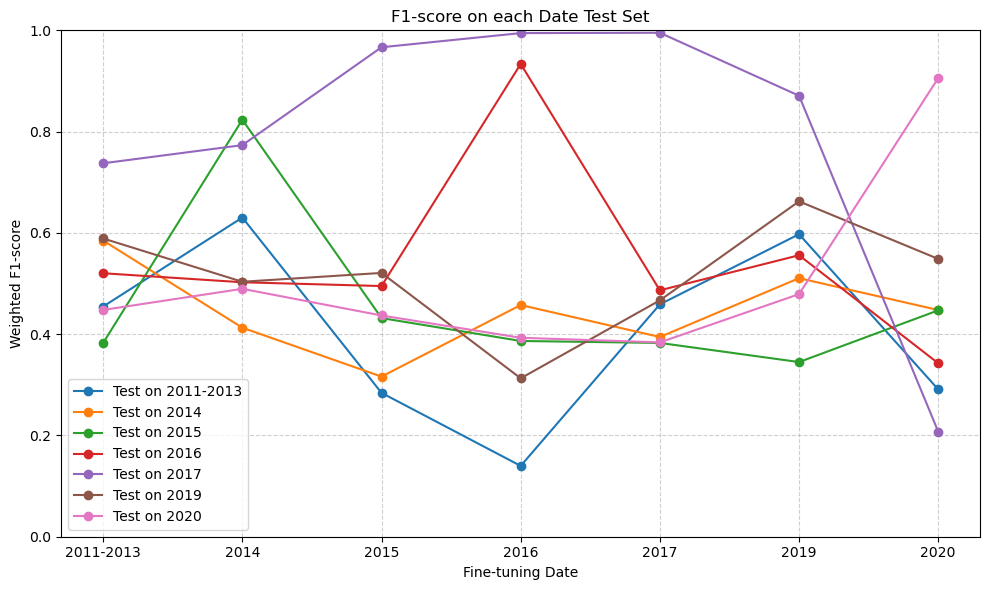

In [17]:
# ------------------
# Plot on each Date
# ------------------

# extract dates
dates = list(results_date.keys())
test_dates = list(next(iter(results_date.values())).keys())

# make F1-score matrix
f1_matrix = np.array([[results_date[train_date][test_date] for test_date in test_dates] for train_date in dates])
plt.figure(figsize=(10, 6))

# plot each test date line
for i, test_date in enumerate(test_dates):
    plt.plot(dates, f1_matrix[:, i], marker='o', label=f"Test on {test_date}")

plt.title("F1-score on each Date Test Set")
plt.xlabel("Fine-tuning Date")
plt.ylabel("Weighted F1-score")
plt.ylim(0, 1)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

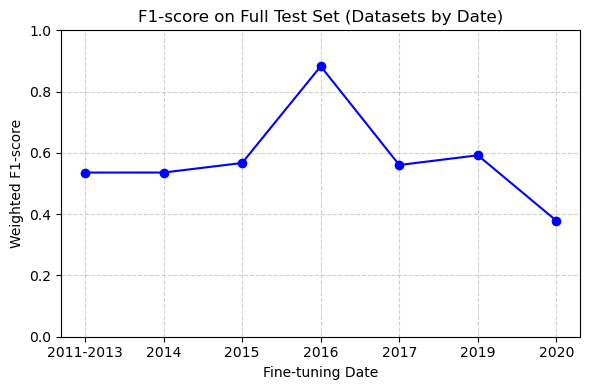

In [ ]:
# ---------------------
# Plot on Full Test Set
# ---------------------

plt.figure(figsize=(6, 4))

# plot F1-score on full test set
plt.plot(dates, [results_full[date] for date in dates], marker='o', color='b')

plt.title("F1-score on Full Test Set (Datasets by Date)")
plt.xlabel("Fine-tuning Date")
plt.ylabel("Weighted F1-score")
plt.ylim(0, 1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()